<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week04_deutsch_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Multi-qubit circuits: Deutsch Algorithm

In [ ]:
!pip install qiskit qiskit_aer qiskit-ibm-runtime pylatexenc

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

The **Deutsch** algorithm is a foundational quantum algorithm first devised to better understand the type of problems that could be solved faster on a quantum computer. A few key things to keep in mind about the algorithm:


1.   It is an algorithm conceived and analysed within the **query model of computation** -- roughly, what this means is we're given a quantum black box (called an oracle) that computes some function.
2. The algorithm can query the black box with any (valid) inputs, observe the respective outputs, but -- as the term black box indicates -- is **not** allowed to peek inside.
3. The objective is to *learn* the function with as few queries as possible. Indeed, within the query model, number of queries is the only measure of efficiency.
4. For the algorithm, we know two additional things about the oracle:

*   It implements a function $f:\{0,1\}\to \{0,1\}$, i.e. takes $0$ or $1$ as input, spits out a $0$ or $1$ as output.

*   Note that any function of this type is either **constant** (i.e. all input strings output $0$ or all of them output $1$) or **balanced** (exactly half of the input strings output $1$.
5. The Deutsch algorithm tries to learn whether the black box $f$ is balanced or constant.

**Question**: How many queries would one need (in the worst case)?

**1. Building the two constant and two balanced oracles.**

In [ ]:
def constant_oracle_0(qc, q0, q1):
    """Oracle that always outputs 0 (does nothing)"""
    pass

def constant_oracle_1(qc, q0, q1):
    """Oracle that always outputs 1 (flips the target qubit)"""
    qc.x(q1)

def balanced_oracle_identity(qc, q0, q1):
    """Oracle that outputs f(x) = x"""
    qc.cx(q0, q1)

def balanced_oracle_negation(qc, q0, q1):
    """Oracle that outputs f(x) = NOT x"""
    qc.x(q0)
    qc.cx(q0, q1)
    qc.x(q0)

**2. Building the Deutsch algorithm circuit**

In [ ]:
def deutsch_algorithm(oracle_function):
    """
    Implements the Deutsch algorithm for a given oracle.

    Args:
        oracle_function: One of the oracle functions defined above

    Returns:
        QuantumCircuit: The complete Deutsch algorithm circuit
    """
    # Create quantum and classical registers
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(1, 'c')
    qc = QuantumCircuit(qr, cr)

    # Step 1: Initialize |01> state
    qc.x(qr[1])
    qc.barrier()

    # Step 2: Apply Hadamard gates to both qubits
    qc.h(qr[0])
    qc.h(qr[1])
    qc.barrier()

    # Step 3: Apply the oracle
    oracle_function(qc, qr[0], qr[1])
    qc.barrier()

    # Step 4: Apply Hadamard gate to the first qubit
    qc.h(qr[0])
    qc.barrier()

    # Step 5: Measure the first qubit
    qc.measure(qr[0], cr[0])

    return qc

**3. Visualizing the circuits**

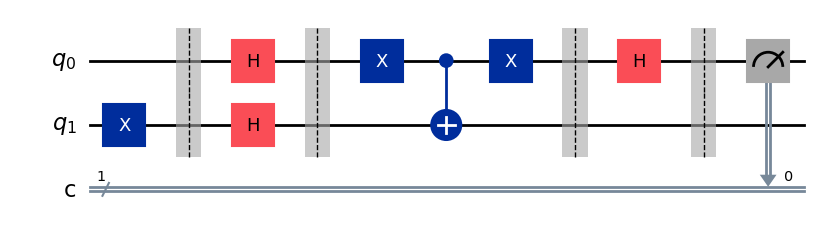

In [ ]:
# Draw the circuit for one of the oracles as an example
example_circuit = deutsch_algorithm(balanced_oracle_negation)
example_circuit.draw(output='mpl')

**4. Run the algorithm for each oracle type**

In [ ]:
# Dictionary of oracles
oracles = {
    'Constant (f(x)=0)': constant_oracle_0,
    'Constant (f(x)=1)': constant_oracle_1,
    'Balanced (f(x)=x)': balanced_oracle_identity,
    'Balanced (f(x)=NOT x)': balanced_oracle_negation
}

# Initialize the simulator
simulator = AerSimulator()

# Run Deutsch algorithm for each oracle
results = {}
for name, oracle in oracles.items():
    # Create circuit
    circuit = deutsch_algorithm(oracle)

    # Execute the circuit
    job = simulator.run(circuit, shots=1024)
    result = job.result()
    counts = result.get_counts()

    # Store results
    results[name] = counts

    print(f"\n{name}:")
    print(f"Measurement results: {counts}")
    if '0' in counts and counts.get('0', 0) > counts.get('1', 0):
        print("Function is CONSTANT")
    else:
        print("Function is BALANCED")


Constant (f(x)=0):
Measurement results: {'0': 1024}
→ Function is CONSTANT

Constant (f(x)=1):
Measurement results: {'0': 1024}
→ Function is CONSTANT

Balanced (f(x)=x):
Measurement results: {'1': 1024}
→ Function is BALANCED

Balanced (f(x)=NOT x):
Measurement results: {'1': 1024}
→ Function is BALANCED
